# S&P 500 Cross-Sectional Return Analysis

## Project snapshot

| | |
|---|---|
| **Goal** | Compare historical performance, volatility, and co-movement across a broad equity universe. |
| **Data** | Ten years of adjusted close prices for current S&P 500 symbols, with 456 equities retained after coverage filtering. |
| **Approach** | Data-quality audit, daily returns, normalized growth, annualized arithmetic return/volatility, and pairwise correlations. |
| **Evaluation** | Descriptive coverage checks and cross-sectional risk/return and correlation summaries; this is not a predictive model. |
| **Observed result** | 2,513 sessions were analysed; average pairwise daily-return correlation was 0.327. |

> **Scope:** Applying today’s constituent list to ten years of prices introduces survivorship and membership bias. Annualized return is mean daily return multiplied by 252, not CAGR, and the return-to-risk ratio does not subtract a risk-free rate. Treat the rankings as descriptive analysis rather than an investable backtest.

## 1. Download and inspect S&P 500 price data

We first fetch the official S&P 500 constituents, convert symbols to Yahoo Finance format when needed, and download historical close prices for the full universe.

Loaded cached prices from datasets/sp500_close_10y.csv
Tickers not returned by data provider: 27
S&P 500 symbols fetched: 503
Tickers kept with sufficient data: 456
Tickers excluded after coverage filter: 47
Trading days in analysis window: 2513


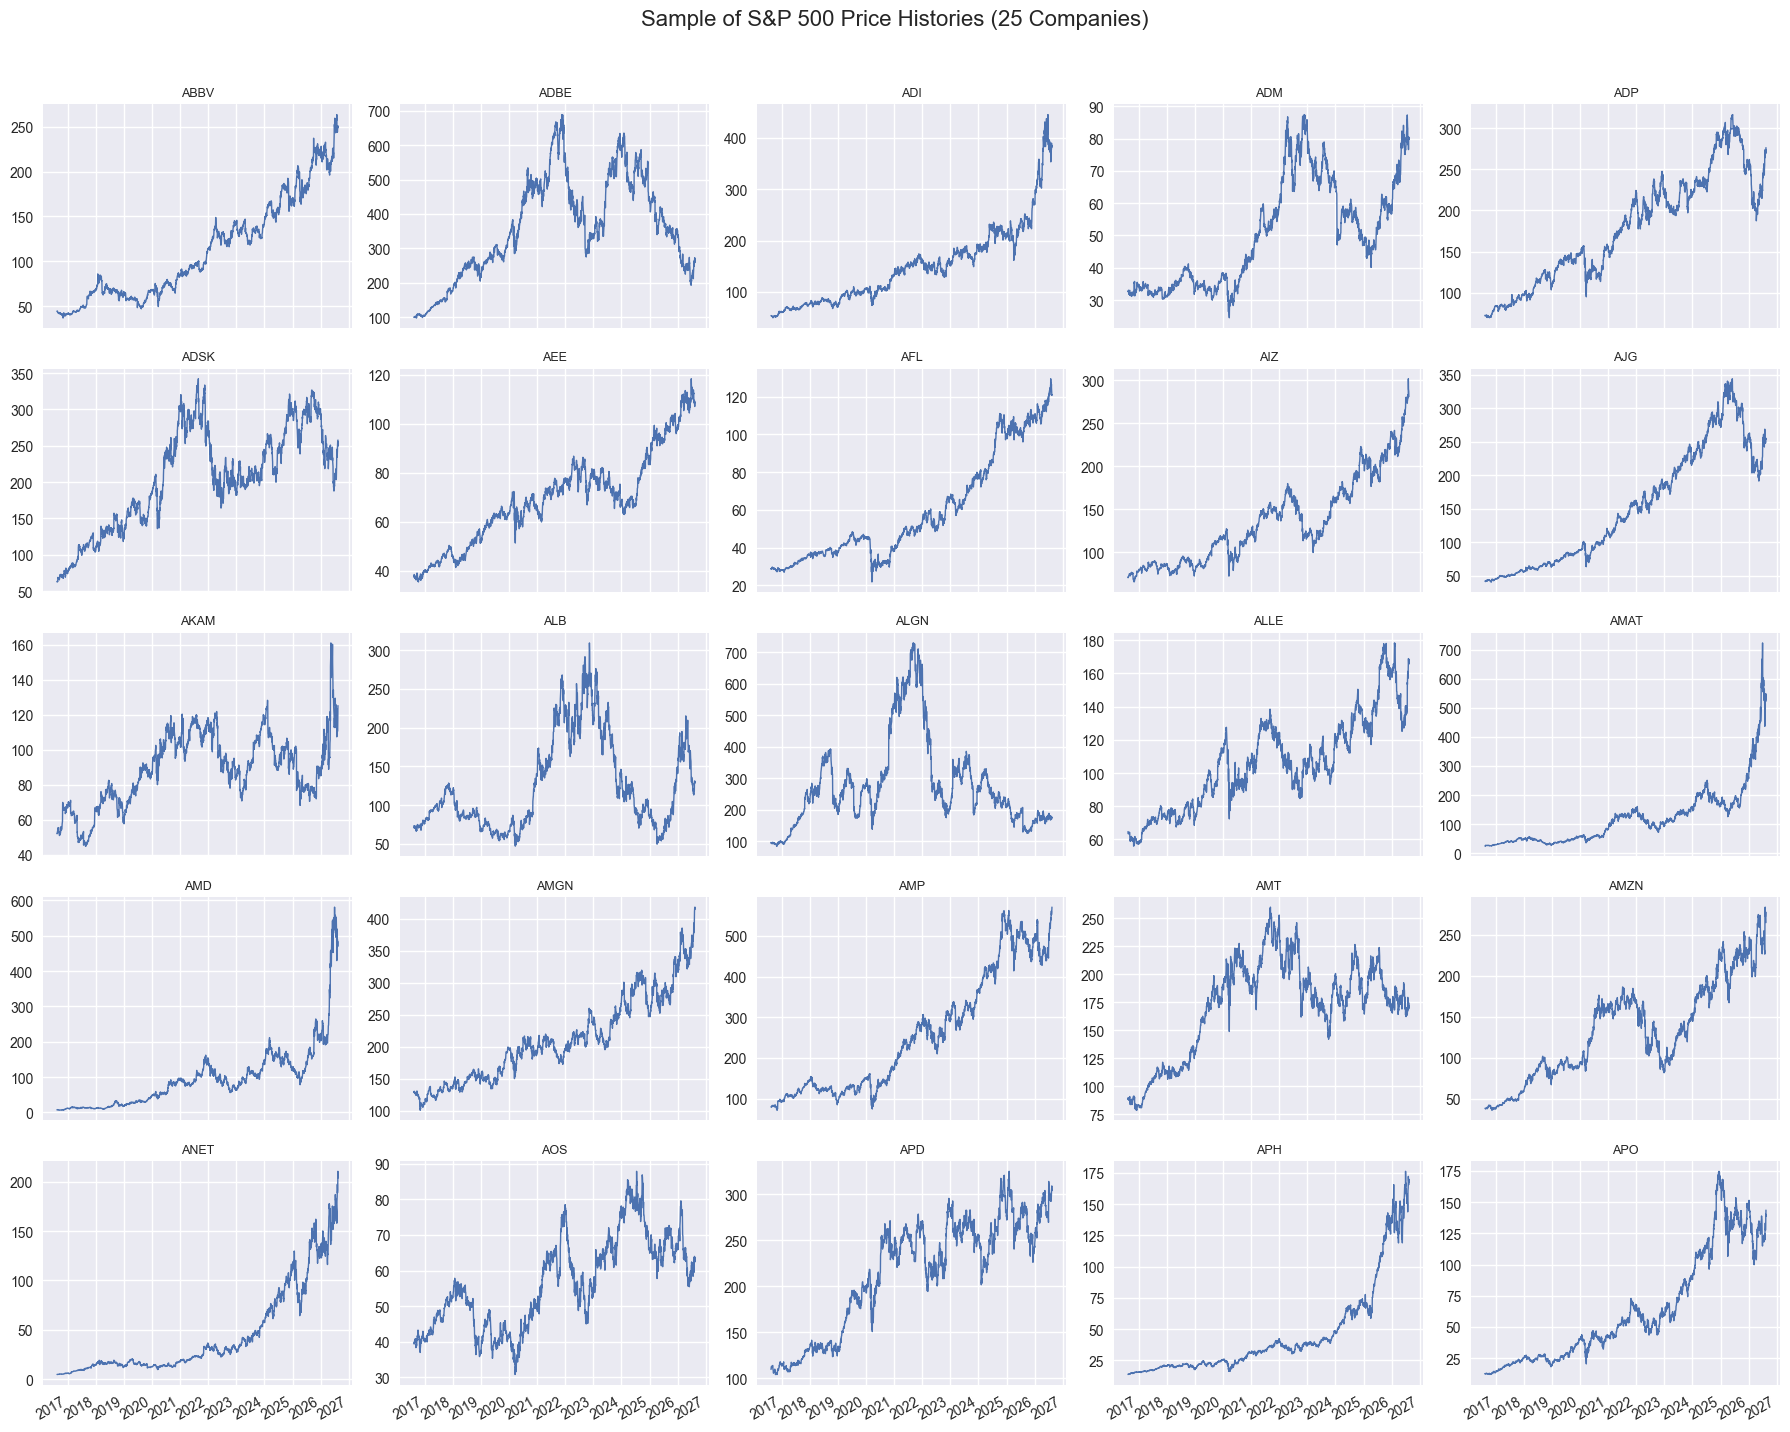

In [28]:
from io import StringIO
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import yfinance as yf

for candidate in (Path.cwd(), *Path.cwd().parents):
    if (candidate / "portfolio_utils").is_dir():
        repo_root = candidate
        break
else:
    raise FileNotFoundError("Could not locate the repository root.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from portfolio_utils import DATASETS_DIR, REPO_ROOT

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 20)

sp500_url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}
response = requests.get(sp500_url, headers=headers, timeout=30)
response.raise_for_status()
sp500_table = pd.read_html(StringIO(response.text), match="Symbol")[0]
tickers = sp500_table["Symbol"].str.replace(".", "-", regex=False).tolist()

cache_path = DATASETS_DIR / "sp500_close_10y.csv"
force_refresh = False


def download_prices_in_batches(symbols, batch_size=75):
    close_frames = []

    for start in range(0, len(symbols), batch_size):
        batch = symbols[start : start + batch_size]
        print(f"Downloading batch {start // batch_size + 1}: {len(batch)} symbols")

        history = yf.download(
            tickers=batch,
            period="10y",
            interval="1d",
            auto_adjust=True,
            progress=False,
            threads=True,
        )

        if history.empty:
            continue

        if isinstance(history.columns, pd.MultiIndex):
            close = history["Close"].copy()
        else:
            close = history.copy()

        if isinstance(close, pd.Series):
            close = close.to_frame(name=batch[0])

        close_frames.append(close)

    if not close_frames:
        raise ValueError("No price data could be downloaded for the S&P 500 universe.")

    prices_out = pd.concat(close_frames, axis=1).sort_index()
    prices_out = prices_out.loc[:, ~prices_out.columns.duplicated()]
    return prices_out


if cache_path.exists() and not force_refresh:
    prices = pd.read_csv(cache_path, index_col=0, parse_dates=True)
    prices.index.name = "Date"
    print(f"Loaded cached prices from {cache_path.relative_to(REPO_ROOT)}")
else:
    prices = download_prices_in_batches(tickers, batch_size=75)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    prices.to_csv(cache_path)
    print(f"Saved downloaded prices to {cache_path.relative_to(REPO_ROOT)}")

raw_missing_tickers = sorted(set(tickers) - set(prices.columns))
if raw_missing_tickers:
    print(f"Tickers not returned by data provider: {len(raw_missing_tickers)}")

min_observations = int(0.70 * len(prices.index))
prices = prices.dropna(axis=1, thresh=min_observations).sort_index()

filtered_missing_tickers = sorted(set(tickers) - set(prices.columns))
print(f"S&P 500 symbols fetched: {len(tickers)}")
print(f"Tickers kept with sufficient data: {prices.shape[1]}")
print(f"Tickers excluded after coverage filter: {len(filtered_missing_tickers)}")
print(f"Trading days in analysis window: {prices.shape[0]}")

sample_tickers = list(prices.columns[:25])
fig, axes = plt.subplots(5, 5, figsize=(18, 14), sharex=True)
for ax, ticker in zip(axes.flat, sample_tickers):
    prices[ticker].dropna().plot(ax=ax, linewidth=1)
    ax.set_title(ticker, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes.flat[len(sample_tickers):]:
    ax.axis("off")

fig.suptitle("Sample of S&P 500 Price Histories (25 Companies)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 2. Inspect the raw downloaded data

This step checks the structure and quality of the downloaded dataset before computing return metrics.

In [23]:
missing_percent = (prices.isna().mean() * 100).sort_values(ascending=False)
coverage = pd.DataFrame(
    {
        "first_date": prices.apply(lambda s: s.first_valid_index()),
        "last_date": prices.apply(lambda s: s.last_valid_index()),
        "missing_percent": missing_percent,
    }
).sort_values("missing_percent")

print("Price table preview (first 5 rows, first 10 tickers):")
display(prices.iloc[:5, :10])

print("Price table preview (last 5 rows, first 10 tickers):")
display(prices.iloc[-5:, :10])

print("Tickers with the best data coverage:")
display(coverage.head(10))

print("Tickers with the weakest data coverage:")
display(coverage.tail(10))

Price table preview (first 5 rows, first 10 tickers):


Ticker,ABBV,ADBE,ADI,ADM,ADP,ADSK,AEE,AFL,AIZ,AJG
Date,,,,,,,,,,
2016-08-15,44.703762,100.930000,54.076733,32.802650,72.605820,62.980000,37.718361,28.811684,70.659592,41.978241
2016-08-16,44.272564,100.599998,53.753620,32.577812,71.970963,62.650002,37.276905,28.621405,70.165451,41.526962
2016-08-17,44.332283,99.699997,53.190239,32.697723,71.786148,62.790001,37.942818,28.807726,70.667862,41.382202
2016-08-18,44.292473,100.669998,53.132229,32.652760,72.187943,63.500000,38.421703,28.645182,70.947884,41.314075
2016-08-19,44.511372,100.320000,53.140507,32.585304,72.204002,63.740002,37.838070,28.890974,71.549149,41.331112


Price table preview (last 5 rows, first 10 tickers):


Ticker,ABBV,ADBE,ADI,ADM,ADP,ADSK,AEE,AFL,AIZ,AJG
Date,,,,,,,,,,
2026-08-07,246.039993,265.209991,389.929993,76.589996,271.320007,249.080002,108.839996,124.610001,289.549988,248.119995
2026-08-10,247.970001,272.959991,383.929993,80.489998,273.679993,256.070007,107.000000,121.940002,287.220001,252.429993
2026-08-11,250.089996,263.709991,385.299988,80.459999,271.089996,251.589996,107.820000,121.070000,281.410004,253.509995
2026-08-12,248.759995,258.750000,384.429993,79.730003,269.329987,249.509995,108.820000,120.730003,281.119995,255.460007
2026-08-13,250.820007,270.489990,381.170013,80.150002,276.230011,257.959991,109.120003,121.099998,280.920013,253.490005


Tickers with the best data coverage:


,first_date,last_date,missing_percent
Ticker,,,
A,2016-08-15,2026-08-13,0.0
MTD,2016-08-15,2026-08-13,0.0
MTB,2016-08-15,2026-08-13,0.0
MSI,2016-08-15,2026-08-13,0.0
MSFT,2016-08-15,2026-08-13,0.0
MSCI,2016-08-15,2026-08-13,0.0
MS,2016-08-15,2026-08-13,0.0
MRVL,2016-08-15,2026-08-13,0.0
MRSH,2016-08-15,2026-08-13,0.0


Tickers with the weakest data coverage:


,first_date,last_date,missing_percent
Ticker,,,
CVNA,2017-04-28,2026-08-13,7.043374
IR,2017-05-12,2026-08-13,7.441305
VICI,2018-01-02,2026-08-13,13.847990
VRT,2018-08-02,2026-08-13,19.697573
MRNA,2018-12-07,2026-08-13,23.199363
FOXA,2019-03-12,2026-08-13,25.706327
FOX,2019-03-13,2026-08-13,25.746120
DOW,2019-03-20,2026-08-13,25.945086
CTVA,2019-05-24,2026-08-13,27.775567


## 3. Calculate daily returns

Daily returns convert prices to percentage changes, which makes cross-company comparison fair despite different absolute share prices.

In [29]:
daily_returns = prices.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).dropna(how="all")

return_summary = daily_returns.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]).T

print("Daily return summary preview:")
display(return_summary[["mean", "std", "1%", "5%", "50%", "95%", "99%"]].head(15))

Daily return summary preview:


,mean,std,1%,5%,50%,95%,99%
ABBV,0.000822,0.016344,-0.045466,-0.022850,0.001088,0.023956,0.042350
ADBE,0.000636,0.021991,-0.063888,-0.033396,0.001253,0.031414,0.057061
ADI,0.000995,0.020851,-0.052752,-0.031145,0.001050,0.030881,0.056150
ADM,0.000503,0.017005,-0.051268,-0.024720,0.000853,0.024882,0.043078
ADP,0.000654,0.015580,-0.044304,-0.022640,0.000997,0.021459,0.040316
ADSK,0.000827,0.023062,-0.062576,-0.034157,0.001155,0.032706,0.060152
AEE,0.000519,0.013811,-0.036622,-0.019436,0.000894,0.018584,0.032998
AFL,0.000703,0.016223,-0.043106,-0.021834,0.001152,0.020258,0.039043
AIZ,0.000695,0.016979,-0.042252,-0.023594,0.001031,0.022210,0.047013
AJG,0.000826,0.014742,-0.040573,-0.021474,0.001413,0.021945,0.036693


## 4. Normalize prices to compare performance over time

We normalize each stock to 1.0 at its first valid observation so growth paths are comparable on the same scale.

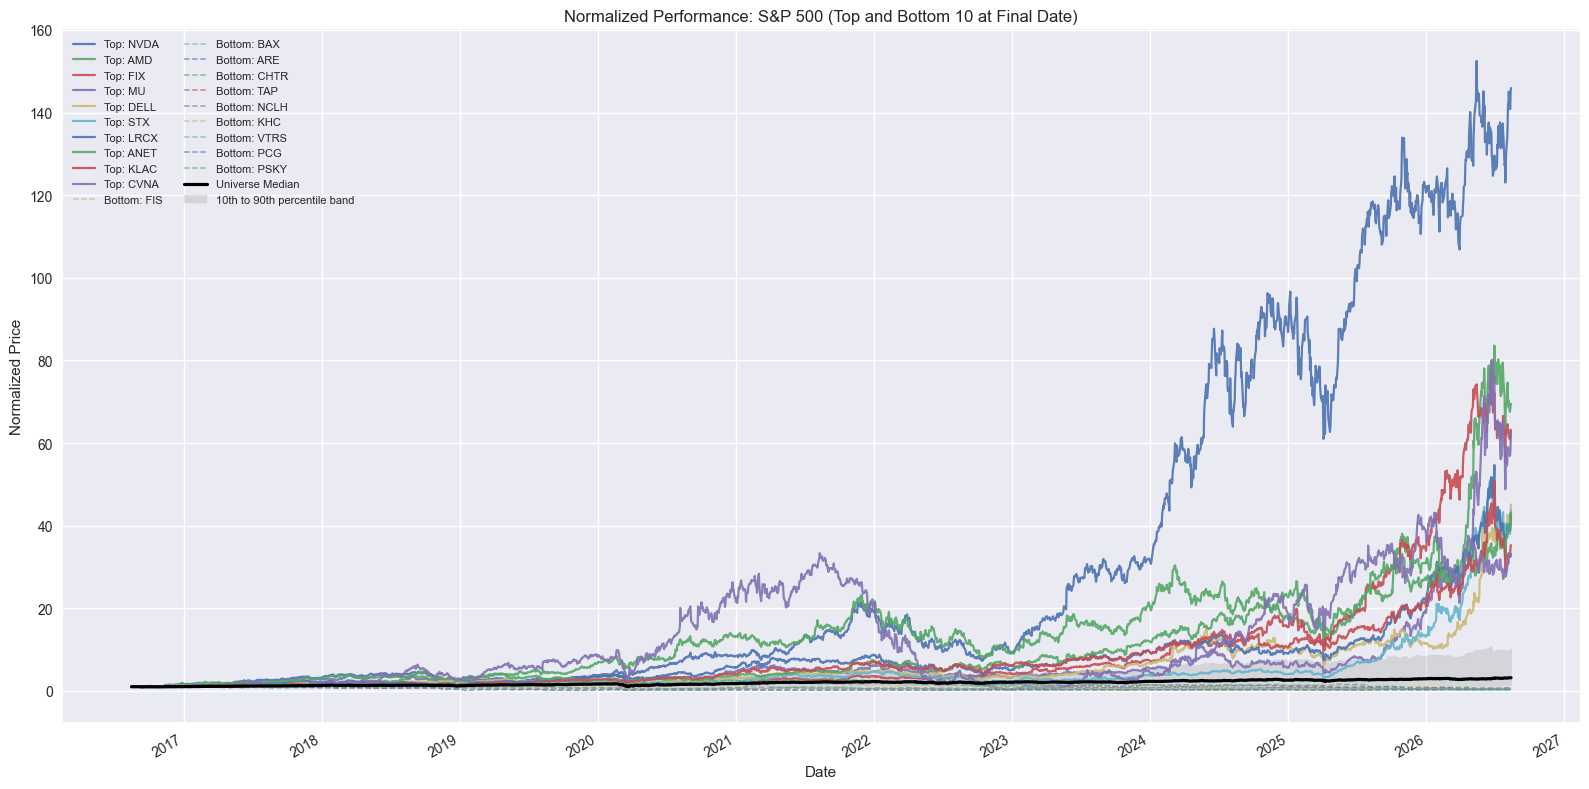

In [25]:
normalized_prices = prices.ffill().dropna(how="all")
normalized_prices = normalized_prices.apply(
    lambda s: s / s.dropna().iloc[0] if s.notna().any() else s
)

terminal_performance = normalized_prices.iloc[-1].dropna().sort_values(ascending=False)
top_10 = terminal_performance.head(10).index
bottom_10 = terminal_performance.tail(10).index

median_path = normalized_prices.median(axis=1)
p10_path = normalized_prices.quantile(0.10, axis=1)
p90_path = normalized_prices.quantile(0.90, axis=1)

plt.figure(figsize=(16, 8))
for ticker in top_10:
    normalized_prices[ticker].plot(label=f"Top: {ticker}", linewidth=1.6, alpha=0.9)
for ticker in bottom_10:
    normalized_prices[ticker].plot(label=f"Bottom: {ticker}", linewidth=1.1, alpha=0.65, linestyle="--")

median_path.plot(color="black", linewidth=2.3, label="Universe Median")
plt.fill_between(
    median_path.index,
    p10_path.values,
    p90_path.values,
    alpha=0.2,
    color="gray",
    label="10th to 90th percentile band",
)

plt.title("Normalized Performance: S&P 500 (Top and Bottom 10 at Final Date)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

## 5. Compare risk against return

Annualized arithmetic mean return is plotted against annualized volatility to compare historical reward and risk across the available companies.

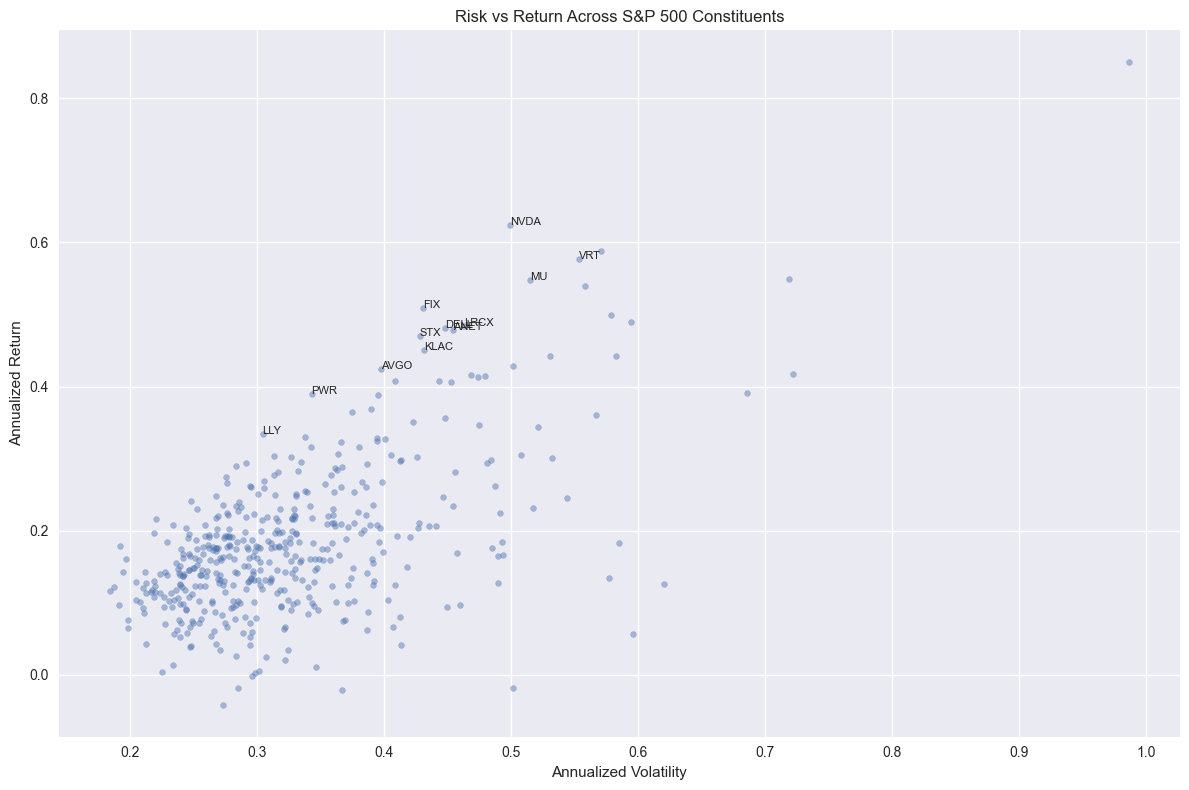

Highest return-to-risk names:


,annualized_return,annualized_volatility,return_to_risk
NVDA,0.624181,0.499662,1.249206
FIX,0.508579,0.430762,1.180649
PWR,0.389564,0.343095,1.135439
STX,0.470803,0.428366,1.099068
LLY,0.333779,0.304545,1.095991
DELL,0.481343,0.448109,1.074165
AVGO,0.423824,0.397734,1.065597
MU,0.547495,0.514764,1.063584
ANET,0.477973,0.454165,1.052422
KLAC,0.450903,0.431831,1.044166


In [30]:
annualized_return = daily_returns.mean() * 252
annualized_volatility = daily_returns.std() * np.sqrt(252)

risk_return = pd.DataFrame(
    {
        "annualized_return": annualized_return,
        "annualized_volatility": annualized_volatility,
    }
).dropna()

risk_return = risk_return[risk_return["annualized_volatility"] > 0]
risk_return["return_to_risk"] = (
    risk_return["annualized_return"] / risk_return["annualized_volatility"]
)

plt.figure(figsize=(12, 8))
plt.scatter(
    risk_return["annualized_volatility"],
    risk_return["annualized_return"],
    s=18,
    alpha=0.45,
)

highlight = risk_return.nlargest(12, "return_to_risk")
for ticker, row in highlight.iterrows():
    plt.annotate(
        ticker,
        (row["annualized_volatility"], row["annualized_return"]),
        fontsize=8,
    )

plt.title("Risk vs Return Across S&P 500 Constituents")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.tight_layout()
plt.show()

print("Highest return-to-risk names:")
display(risk_return.sort_values("return_to_risk", ascending=False).head(15))

## 6. Examine return correlations

This computes pairwise correlation for the full universe, then visualizes a readable subset while still reporting full-universe correlation statistics.

Average pairwise correlation (full universe): 0.327
Median pairwise correlation (full universe): 0.321
Most positively correlated pairs:


GOOGL  GOOG    0.995462
FOX    FOXA    0.987203
NWSA   NWS     0.971944
EQR    AVB     0.919604
UDR    EQR     0.918604
REG    FRT     0.914606
LRCX   AMAT    0.910035
RF     FITB    0.907519
KEY    CFG     0.906878
UDR    AVB     0.904978
dtype: float64

Most negatively correlated pairs:


VRT   GIS    -0.117091
FANG  CLX    -0.093789
CLX   APA    -0.071318
MU    GIS    -0.069133
VRT   HRL    -0.066112
      SJM    -0.064566
MRVL  GIS    -0.061563
CRWD  SJM    -0.056431
VRT   ED     -0.054362
ED    CRWD   -0.052331
dtype: float64

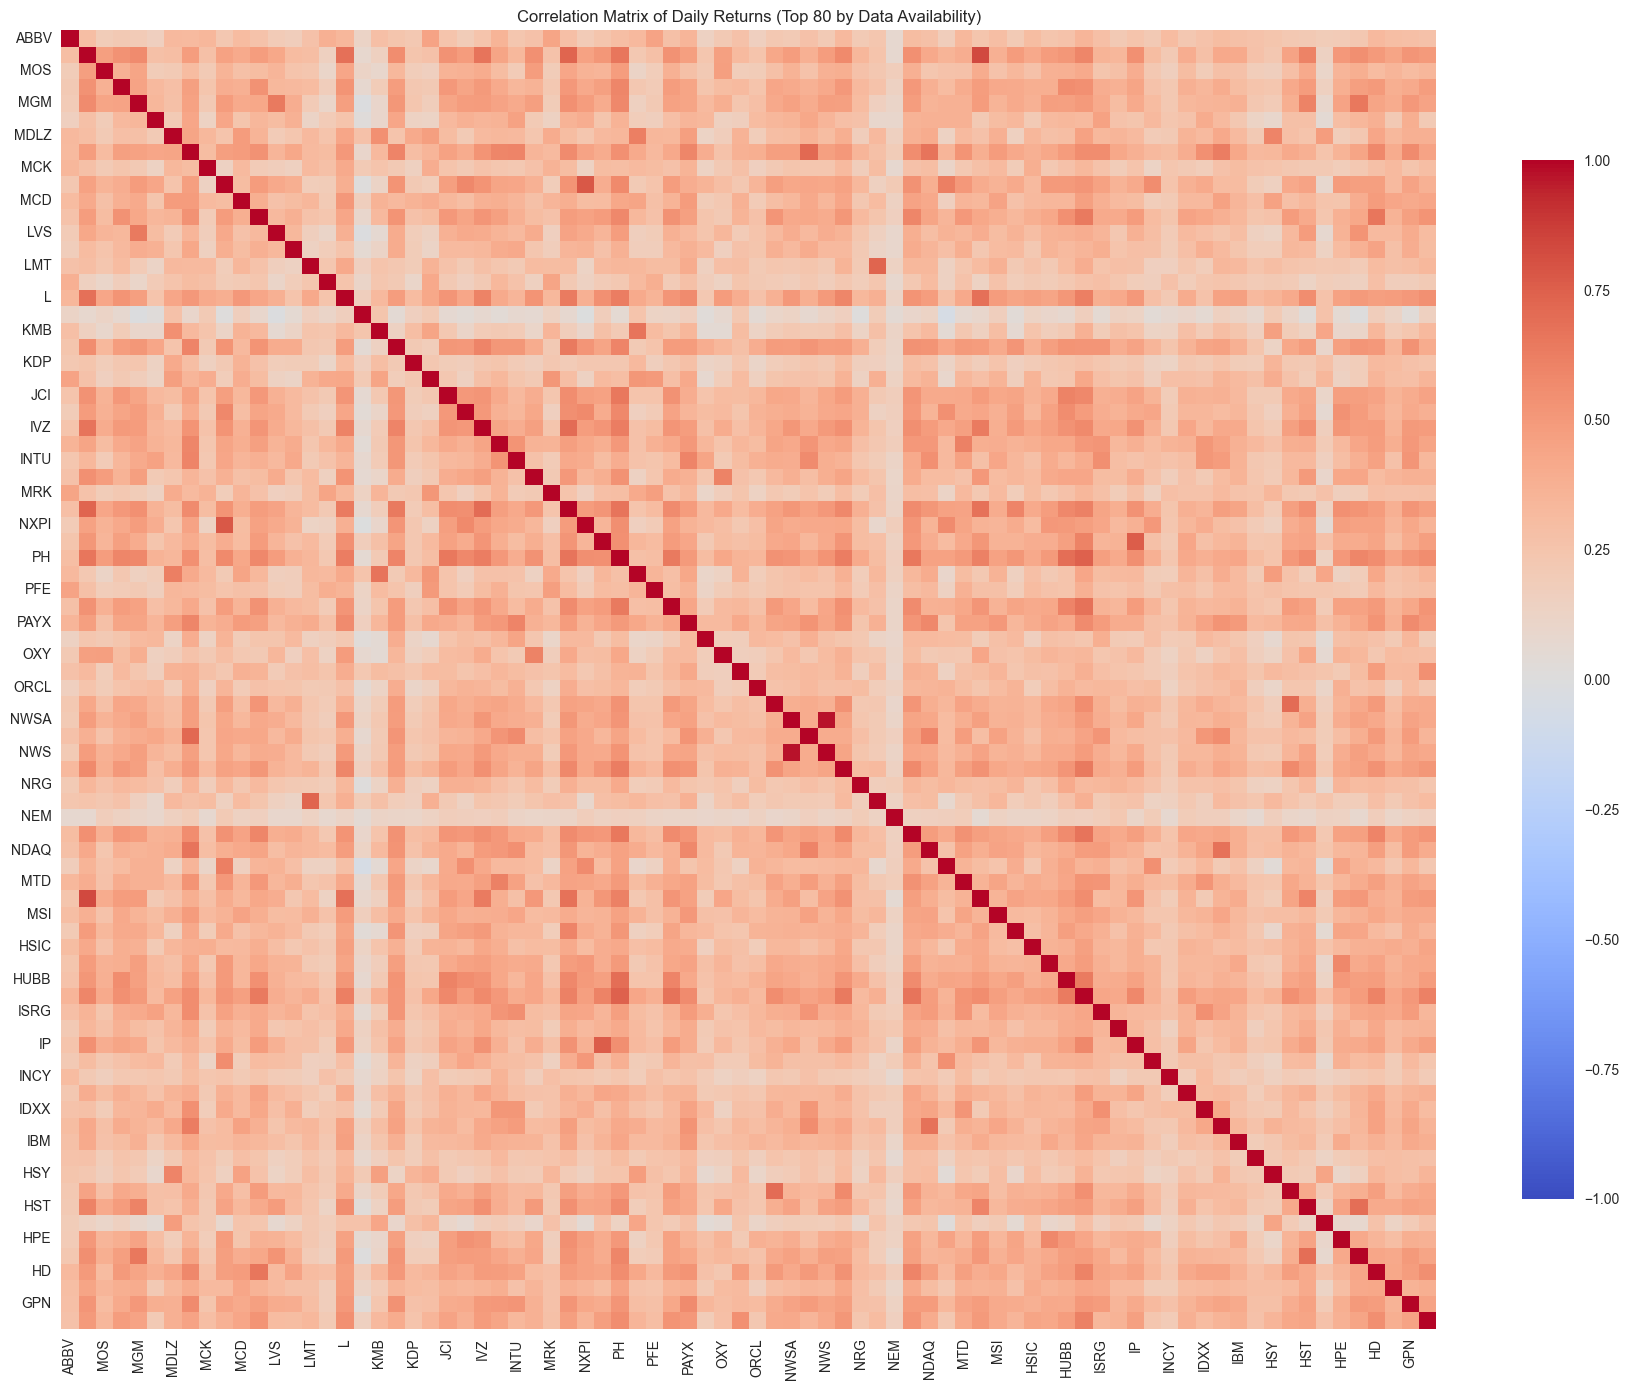

In [31]:
corr_matrix = daily_returns.corr()

upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=0)
pairwise_corr = corr_matrix.where(~upper_mask).stack()

print(f"Average pairwise correlation (full universe): {pairwise_corr.mean():.3f}")
print(f"Median pairwise correlation (full universe): {pairwise_corr.median():.3f}")

print("Most positively correlated pairs:")
display(pairwise_corr.sort_values(ascending=False).head(10))

print("Most negatively correlated pairs:")
display(pairwise_corr.sort_values().head(10))

heatmap_tickers = daily_returns.notna().sum().sort_values(ascending=False).head(80).index

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix.loc[heatmap_tickers, heatmap_tickers],
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix of Daily Returns (Top 80 by Data Availability)")
plt.tight_layout()
plt.show()

## 7. Results and takeaways

The final panel covers **456 current-index equities across 2,513 trading sessions** after applying the coverage filter. Daily returns had an average pairwise correlation of **0.327**, showing meaningful common market movement alongside substantial cross-sectional variation. The risk/return view highlights historical standouts, while the correlation analysis identifies both near-duplicate share classes and broader sector co-movement.

The common correlation level highlights a material market component, while the remaining dispersion shows why single-stock risk and sector exposure still matter. The charts are most useful for exploratory comparison, not security selection.

## Limitations and next steps

- Using current constituents over the full lookback excludes many historical removals and creates survivorship and membership bias.
- Unequal listing histories and the coverage filter change which equities enter each pairwise statistic.
- Arithmetic annualization is not CAGR, and the return-to-risk ratio is not a Sharpe ratio because no risk-free rate is deducted.
- Rebuild the universe from point-in-time membership, add delisted securities, define a fixed analysis end date, and report confidence intervals or rolling regimes before investment interpretation.
